# Тестовое задание: детекция ботов

Порядок работы: EDA, Feature Engineering, временная валидация, сравнение моделей, устойчивость и ансамбли, финальная проверка на holdout, итоговые прогнозы. 
! Полный пересчет всех экспериментов занимает около 57 минут на CPU.
Версия Python **3.12.14**

## 1. EDA и качество данных

Связи с target исследуем только на валидационной выборке, 6-16 апреля. Последние три дня используются как holdout set после выбора конфигурации.

In [1]:
from pathlib import Path
import hashlib
import sys
import time
import warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import precision_recall_curve, confusion_matrix, average_precision_score, roc_auc_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

SEED = 42
HOLDOUT_START = pd.Timestamp('2026-04-17')
warnings.filterwarnings('error', category=ConvergenceWarning)
thread_limits = threadpool_limits(limits=4)
np.random.seed(SEED)
pd.set_option('display.max_columns', 16)
pd.set_option('display.max_rows', 40)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {0: '#376C9E', 1: '#CE7B28'}

In [2]:
date_columns = ['cookie_created_at', 'window_start_ts', 'window_end_ts']
train = pd.read_csv('data/train.csv', parse_dates=date_columns)
test = pd.read_csv('data/test.csv', parse_dates=date_columns)
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])
sample = pd.read_csv('sample_submission.csv')
meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
validation = train.loc[train['window_end_ts'].le(HOLDOUT_START)].copy()
holdout = train.loc[train['window_start_ts'].ge(HOLDOUT_START)].copy()

assert train.cookie_id.is_unique and test.cookie_id.is_unique # проверка уникальности id
display(pd.DataFrame({'rows': [len(train), len(test), len(events)],
                      'columns': [train.shape[1], test.shape[1], events.shape[1]]},
                     index=['train', 'test', 'events']))
display(train.head(3))
display(events.head(3))

,rows,columns
train,11091,5
test,4909,4
events,328905,14


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0000,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0000,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0000,kvartiry_prodazha,kirov,private,NaN,NaN,675.0000,276.0000


### 1.1. Объем и баланс по дням

,cookies,positive,positive_share
window_start_ts,,,
2026-04-06,772,68,0.0881
2026-04-07,797,59,0.0740
2026-04-08,834,70,0.0839
2026-04-09,902,66,0.0732
2026-04-10,912,82,0.0899
2026-04-11,896,79,0.0882
2026-04-12,817,67,0.0820
2026-04-13,843,53,0.0629
2026-04-14,826,70,0.0847


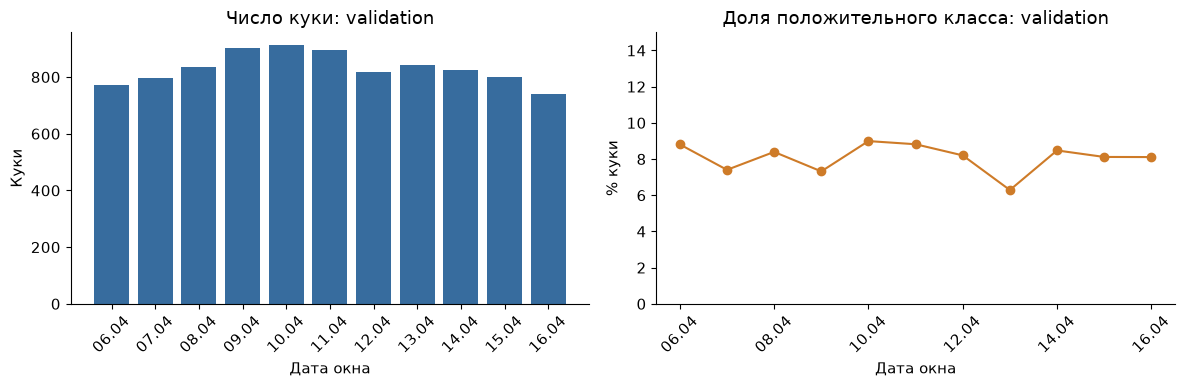

In [3]:
daily = validation.groupby('window_start_ts')['target'].agg(['size', 'sum', 'mean'])
display(daily.rename(columns={'size': 'cookies', 'sum': 'positive', 'mean': 'positive_share'}))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(daily.index.strftime('%d.%m'), daily['size'], color=COLORS[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set(title='Число куки: validation', xlabel='Дата окна', ylabel='Куки')
axes[1].plot(daily.index, daily['mean'] * 100, marker='o', color=COLORS[1])
axes[1].set(title='Доля положительного класса: validation', xlabel='Дата окна', ylabel='% куки', ylim=(0, 15))
axes[1].set_xticks(daily.index[::2], daily.index[::2].strftime('%d.%m'), rotation=45)
fig.tight_layout()
plt.show()

### 1.2. Окна наблюдения и дубликаты

Проверяем данные до удаления строк: особенно важно не включить реакцию антибота
после конца окна. Полный дубликат считаем повторной записью лога и удаляем.
Это допущение: без event_id нельзя окончательно отличить дубль от двух одинаковых
действий в одну секунду. Совпадение только cookie и времени не считается дублем.

In [4]:
# Схему событий берем из первого дня train, входящего во все обучающие фолды.
event_names = (events.loc[events.cookie_id.isin(train.loc[
    train.window_end_ts.eq(train.window_end_ts.min()), 'cookie_id']), ['eid', 'event_name']]
    .drop_duplicates().sort_values('eid').event_name.tolist())


def prepare_events(events, meta, drop_duplicates=True):
    """Окно [start, end), точные дубликаты и нормализация платформ."""
    events = events.copy()
    events['event_ts'] = pd.to_datetime(events['event_ts'], errors='coerce')
    events = events.merge(
        meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
        on='cookie_id', how='left', validate='many_to_one',
    )
    in_window = (
        events['event_ts'].ge(events['window_start_ts'])
        & events['event_ts'].lt(events['window_end_ts'])
    )
    events = events.loc[in_window].copy()
    if drop_duplicates:
        events = events.drop_duplicates()
    events['platform'] = (
        events['platform'].str.strip().str.lower()
        .replace({'desktop': 'web', 'iphone': 'ios'})
    )
    # При одинаковом времени порядок событий неизвестен.
    return events.sort_values(['cookie_id', 'event_ts'], kind='stable')


def category_summary(events, column):
    """Доминирующая категория, ее доля и энтропия известных значений."""
    counts = events.groupby(['cookie_id', column], observed=True).size()
    totals = counts.groupby(level=0).transform('sum')
    shares = counts / totals
    entropy = -(shares * np.log(shares)).groupby(level=0).sum()
    table = counts.rename('count').reset_index()
    table = table.sort_values(['cookie_id', 'count', column], ascending=[True, False, True])
    mode = table.drop_duplicates('cookie_id').set_index('cookie_id')[column]
    return pd.DataFrame({
        f'{column}_mode': mode,
        f'{column}_top_share': shares.groupby(level=0).max(),
        f'{column}_entropy': entropy,
    })

In [5]:
event_audit = events.merge(meta[['cookie_id'] + date_columns], on='cookie_id', validate='many_to_one')
in_window = event_audit['event_ts'].ge(event_audit['window_start_ts']) & event_audit['event_ts'].lt(event_audit['window_end_ts'])
quality = pd.Series({
    'events_raw': len(events),
    'exact_duplicates_raw': int(events.duplicated().sum()),
    'invalid_event_ts': int(events['event_ts'].isna().sum()),
    'before_window': int(event_audit['event_ts'].lt(event_audit['window_start_ts']).sum()),
    'at_or_after_end': int(event_audit['event_ts'].ge(event_audit['window_end_ts']).sum()),
    'before_cookie_creation': int(event_audit['event_ts'].lt(event_audit['cookie_created_at']).sum()),
    'duplicates_inside_window': int(events.loc[in_window].duplicated().sum()),
}, name='rows')
display(quality.to_frame())
window_by_type = pd.crosstab(event_audit['event_name'], in_window).rename(columns={False: 'outside', True: 'inside'})
display(window_by_type)
display(events.groupby('eid')['event_name'].nunique().rename('names_per_eid').to_frame())
clean_events = prepare_events(events, meta)
quality['events_clean'] = len(clean_events)
assert clean_events.event_ts.ge(clean_events.window_start_ts).all()
assert clean_events.event_ts.lt(clean_events.window_end_ts).all()

,rows
events_raw,328905
exact_duplicates_raw,4863
invalid_event_ts,0
before_window,0
at_or_after_end,40779
before_cookie_creation,0
duplicates_inside_window,4293


col_0,outside,inside
event_name,,
captcha_shown,7928,0
contact_chat_open,577,5548
contact_message_sent,258,2823
contact_phone_show,1028,10288
favorite_add,1753,17296
item_view,12731,108086
login,606,5661
photo_swipe,3433,33084
search_results_view,10604,89798


,names_per_eid
eid,
100,1
200,1
210,1
220,1
300,1
301,1
303,1
400,1
500,1


In [6]:
clean_events.shape

(283833, 16)

В исходных данных 328 905 событий. За пределами окон - 40 779; внутри окон
удалены 4 293 точных дубля. Осталось 283 833 события. Все события `captcha_shown`
оказались вне окна: их нельзя использовать. Количество и характеристики действий вне окна в признаки не попадают.

### 1.3. Пропуски, категории и числовые значения

Пропуски проверяем по типам событий. Например, номер страницы поиска не определен
для просмотра объявления; координаты могут отсутствовать на мобильных платформах.
Не будем удалять такие строки или подменять все пропуски нулями.

,missing_share
search_query,0.6888
search_page,0.6888
pointer_x,0.6626
pointer_y,0.6626
seller_type,0.3922
item_id,0.3310
item_category,0.0792
item_location,0.0497
cookie_id,0.0000
event_ts,0.0000


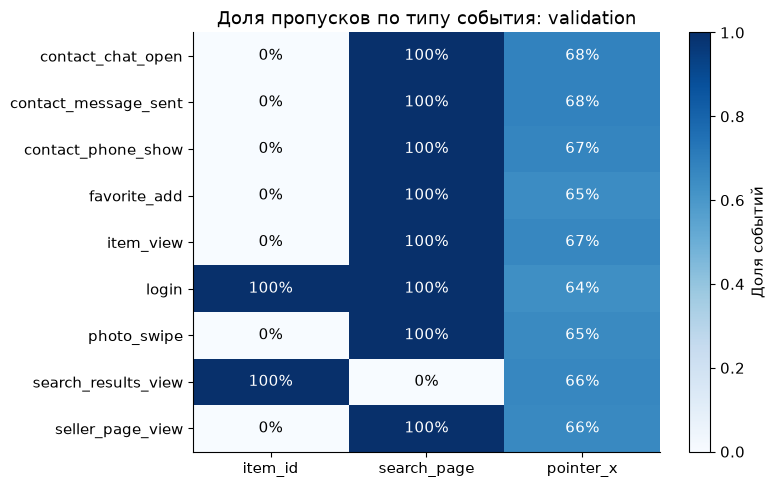

,raw_count
platform,
desktop,46866
WEB,46476
Web,46365
web,45951
ANDROID,42462
Android,42254
android,42159
iphone,4103
IOS,4100


,count,mean,std,min,1%,50%,95%,99%,max
search_page,49801.0000,2.8806,2.8356,1.0000,1.0000,2.0000,8.0000,14.0000,63.0000
pointer_x,54000.0000,929.1471,544.6717,0.0000,14.0000,907.0000,1812.0000,1899.0000,1920.0000
pointer_y,54000.0000,537.9999,305.7448,0.0000,8.0000,535.0000,1025.0000,1070.0000,1080.0000


Отрицательные координаты: 0
Поиск с search_page < 1: 0


In [7]:
eda_events = clean_events.loc[clean_events['cookie_id'].isin(validation['cookie_id'])].copy()
display(eda_events.isna().mean().sort_values(ascending=False).rename('missing_share').to_frame())
missing_by_event = eda_events.groupby('event_name')[['item_id', 'search_page', 'pointer_x']].agg(lambda s: s.isna().mean())
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(missing_by_event, vmin=0, vmax=1, cmap='Blues', aspect='auto')
ax.set_xticks(range(3), missing_by_event.columns)
ax.set_yticks(range(len(missing_by_event)), missing_by_event.index)
for row in range(len(missing_by_event)):
    for col in range(3):
        value = missing_by_event.iloc[row, col]
        ax.text(col, row, f'{value:.0%}', ha='center', va='center', color='white' if value > .6 else 'black')
ax.set_title('Доля пропусков по типу события: validation')
fig.colorbar(im, ax=ax, label='Доля событий')
fig.tight_layout()
plt.show()

display(events['platform'].value_counts().rename('raw_count').to_frame())
display(eda_events[['search_page', 'pointer_x', 'pointer_y']].describe(percentiles=[.01, .5, .95, .99]).T)
print('Отрицательные координаты:', int(eda_events[['pointer_x', 'pointer_y']].lt(0).any(axis=1).sum()))
print('Поиск с search_page < 1:', int(eda_events['search_page'].lt(1).sum()))

Нормализуем названия платформ. Большие значения активности заранее не отсекаем:
они могут быть именно тем сигналом, который ищем.

target                 0        1
n_events count 8401.0000 739.0000
         mean    16.4615  29.4317
         std     15.7475  27.3044
         min      1.0000   1.0000
         25%      6.0000  11.0000
         50%     11.0000  20.0000
         75%     21.0000  38.0000
         max    137.0000 165.0000
n_items  count 8401.0000 739.0000
         mean     8.8325  13.9770
         std      8.9361  11.1634
         min      0.0000   1.0000
         25%      3.0000   6.0000
         50%      6.0000  11.0000
         75%     11.0000  19.0000
         max     80.0000  70.0000

,IQR_upper,above_IQR
n_events,48.5000,549
n_items,25.5000,585


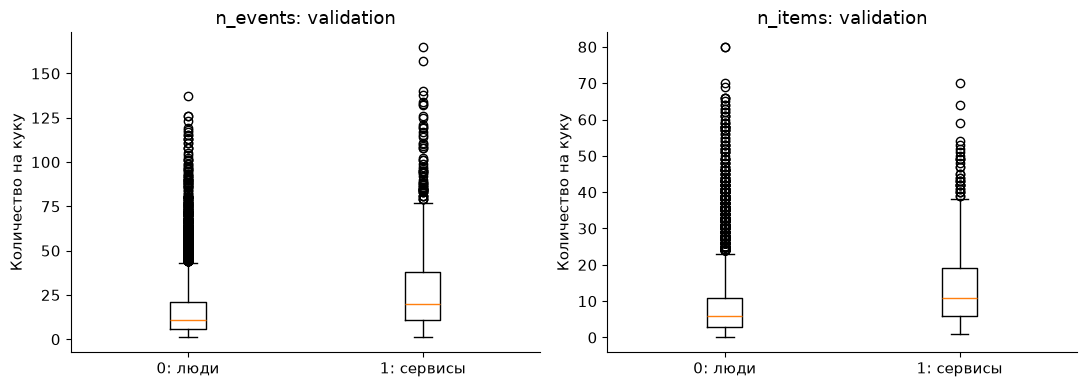

In [8]:
activity = eda_events.groupby('cookie_id').agg(
    n_events=('event_name', 'size'), n_items=('item_id', 'nunique'),
)
activity = validation.set_index('cookie_id')[['target']].join(activity).fillna(0)
display(activity.groupby('target')[['n_events', 'n_items']].describe().T)
quartiles = activity[['n_events', 'n_items']].quantile([.25, .75])
iqr_upper = quartiles.loc[.75] + 1.5 * (quartiles.loc[.75] - quartiles.loc[.25])
display(pd.DataFrame({'IQR_upper': iqr_upper, 'above_IQR': activity[['n_events', 'n_items']].gt(iqr_upper).sum()}))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, column in zip(axes, ['n_events', 'n_items']):
    ax.boxplot([activity.loc[activity.target.eq(label), column] for label in [0, 1]], tick_labels=['0: люди', '1: сервисы'])
    ax.set(title=column + ': validation', ylabel='Количество на куку')
fig.tight_layout()
plt.show()

Медиана числа событий и числа разных объявлений в validation: выше у класса 1. Разброс значений у класса 1 также выше.
Распределения пересекаются, поэтому высокая активность - слабая эвристика, а не правило разметки.
Значения выше границ IQR здесь не являются выбросами, оставляем.

## 2. Признаки из событий

Основные группы признаков:

- Объем активности (число событий, объявлений, поисков)
- Структура активности (доли типов событий, контакты и взаимодействия на просмотр)
- Скорость и регулярность событий (медиана и CV пауз, доля пауз ≤ 2 с, максимум событий в минуту)
- Время (длительность активности, число сессий и активных часов)
- Разнообразие (число категорий и городов, доминирующая доля, энтропия)
- Поиск (глубина выдачи, длина и разнообразие запросов)
- Технические (семейство браузера, доля headless, платформа)
- Координаты (разброс, доля уникальных пар, полнота на web)
- Метаданные (возраст cookie к концу окна)

In [9]:
def make_features(events, meta):
    """Агрегаты без обучения на target и без статистик других куки.

    На вход подаются уже отфильтрованные и очищенные события.
    Отсутствующее количество равно 0; неопределенная статистика остается NaN.
    """
    events = events.copy()
    grouped = events.groupby('cookie_id', sort=False)
    features = meta.set_index('cookie_id')[[]].copy()
    features['n_events'] = grouped.size()
    features['n_events'] = features['n_events'].fillna(0)
    features['no_events'] = features['n_events'].eq(0).astype(int)
    indexed_meta = meta.set_index('cookie_id')
    features['cookie_age_days'] = (
        indexed_meta['window_end_ts'] - indexed_meta['cookie_created_at']
    ).dt.total_seconds() / 86400

    for column in ['item_id', 'item_category', 'item_location', 'search_query',
                   'user_agent', 'platform', 'event_name']:
        features[f'{column}_nunique'] = grouped[column].nunique().fillna(0)
    for column in ['item_id', 'item_category', 'item_location', 'seller_type',
                   'search_query', 'search_page', 'pointer_x', 'pointer_y']:
        features[f'{column}_missing_share'] = (
            events[column].isna().groupby(events['cookie_id']).mean()
        )

    event_counts = pd.crosstab(events['cookie_id'], events['event_name'])
    event_counts = event_counts.reindex(index=features.index, columns=event_names, fill_value=0)
    for name in event_names:
        features[f'{name}_count'] = event_counts[name]
        features[f'{name}_share'] = event_counts[name] / features['n_events'].replace(0, np.nan)
    item_views = features['item_view_count']
    features['unique_interacted_items_per_view'] = features['item_id_nunique'] / item_views.replace(0, np.nan)
    viewed_items = events.loc[events['event_name'].eq('item_view')].groupby('cookie_id')['item_id'].nunique()
    features['unique_viewed_items_share'] = viewed_items.reindex(features.index, fill_value=0) / item_views.replace(0, np.nan)
    features['views_per_search'] = item_views / (features['search_results_view_count'] + 1)
    features['contacts_per_view'] = event_counts[
        ['contact_phone_show', 'contact_chat_open', 'contact_message_sent']
    ].sum(axis=1) / (item_views + 1)
    features['engagement_per_view'] = event_counts[
        ['photo_swipe', 'favorite_add', 'contact_chat_open', 'contact_message_sent']
    ].sum(axis=1) / (item_views + 1)

    # Скорость и регулярность. Межсессионные паузы учитываем отдельно.
    events['gap_seconds'] = grouped['event_ts'].diff().dt.total_seconds()
    events['within_session_gap'] = events['gap_seconds'].where(events['gap_seconds'].le(1800))
    grouped = events.groupby('cookie_id', sort=False)
    for column, prefix in [('gap_seconds', 'gap'), ('within_session_gap', 'session_gap')]:
        stats = grouped[column].agg(['mean', 'median', 'std', 'min', 'max'])
        features = features.join(stats.add_prefix(prefix + '_'))
        features[prefix + '_cv'] = stats['std'] / stats['mean'].replace(0, np.nan)
    for name, indicator in {
        'gap_zero_share': events['gap_seconds'].eq(0),
        'gap_under_2s_share': events['gap_seconds'].le(2),
        'gap_over_30min_share': events['gap_seconds'].gt(1800),
    }.items():
        # У первой строки куки нет предыдущего события: исключаем из знаменателя.
        indicator = indicator.astype(float).where(events['gap_seconds'].notna())
        features[name] = indicator.groupby(events['cookie_id']).mean()
    features['n_sessions'] = (
        (events['gap_seconds'].isna() | events['gap_seconds'].gt(1800))
        .groupby(events['cookie_id']).sum()
    )
    first, last = grouped['event_ts'].min(), grouped['event_ts'].max()
    features['active_span_seconds'] = (last - first).dt.total_seconds()
    features['events_per_active_minute'] = features['n_events'] / (
        features['active_span_seconds'] / 60 + 1
    )
    features['first_event_delay_seconds'] = (first - indexed_meta['window_start_ts']).dt.total_seconds()
    features['last_event_idle_seconds'] = (indexed_meta['window_end_ts'] - last).dt.total_seconds()
    events['hour'] = events['event_ts'].dt.hour
    events['minute'] = events['event_ts'].dt.floor('min')
    features['active_hours'] = events.groupby('cookie_id')['hour'].nunique()
    minute_counts = events.groupby(['cookie_id', 'minute']).size()
    features['max_events_per_minute'] = minute_counts.groupby(level=0).max()
    features['night_share'] = events['hour'].lt(6).groupby(events['cookie_id']).mean()

    # Поисковые запросы не восстанавливаем и не исправляем предположениями.
    query = events['search_query']
    events['query_length'] = query.str.len().astype(float)
    events['query_corrupted'] = query.str.contains('\ufffd', na=False).astype(float).where(query.notna())
    for column in ['search_page', 'query_length']:
        stats = events.groupby('cookie_id')[column].agg(['mean', 'max', 'std'])
        features = features.join(stats.add_prefix(column + '_'))
    features['query_corrupted_share'] = events.groupby('cookie_id')['query_corrupted'].mean()

    # User-Agent можно подменить: это дополнительный сигнал, а не разметка.
    ua = events['user_agent'].str.lower().fillna('')
    patterns = {
        'ua_automation': 'headless|python|requests|curl|scrapy|aiohttp|httpx|bot|crawler|spider',
        'ua_headless': 'headless', 'ua_mobile': 'android|iphone|ipad|mobile',
        'ua_linux': 'linux', 'ua_windows': 'windows', 'ua_mac': 'macintosh',
    }
    for name, pattern in patterns.items():
        features[name + '_share'] = ua.str.contains(pattern).groupby(events['cookie_id']).mean()
    events['browser'] = np.select(
        [ua.str.contains('headless'), ua.str.contains('yabrowser'),
         ua.str.contains('edg/'), ua.str.contains('firefox'),
         ua.str.contains('chrome'), ua.str.contains('safari')],
        ['headless', 'yandex', 'edge', 'firefox', 'chrome', 'safari'], default='other',
    )
    for column in ['platform', 'browser', 'item_category', 'item_location', 'event_name']:
        features = features.join(category_summary(events, column))
    for platform in ['web', 'android', 'ios']:
        features[f'platform_{platform}_share'] = (
            events['platform'].eq(platform).groupby(events['cookie_id']).mean()
        )
    known_seller = events['seller_type'].notna()
    features['seller_pro_share'] = (
        events['seller_type'].eq('pro').astype(float).where(known_seller)
        .groupby(events['cookie_id']).mean()
    )

    # Пропуски координат ожидаемы на мобильных платформах. Считаем также
    # полноту именно web-событий, чтобы не спутать платформу с поведением.
    pointer_known = events['pointer_x'].notna() & events['pointer_y'].notna()
    features['web_pointer_share'] = (
        pointer_known.astype(float).where(events['platform'].eq('web'))
        .groupby(events['cookie_id']).mean()
    )
    pointer_events = events.loc[pointer_known]
    pointer_group = pointer_events.groupby('cookie_id')
    for coordinate in ['pointer_x', 'pointer_y']:
        features[coordinate + '_std'] = pointer_group[coordinate].std()
    unique_pairs = pointer_events.drop_duplicates(['cookie_id', 'pointer_x', 'pointer_y'])
    features['pointer_unique_share'] = (
        unique_pairs.groupby('cookie_id').size() / pointer_group.size()
    )
    # Не используем item_id, cookie_id и календарную дату как признаки.
    categorical = [column for column in features if column.endswith('_mode')]
    features[categorical] = features[categorical].fillna('unknown').astype(str)
    numeric = features.columns.difference(categorical)
    features[numeric] = features[numeric].replace([np.inf, -np.inf], np.nan)
    zero_columns = [c for c in numeric if c.endswith(('_count', '_nunique'))]
    zero_columns += ['n_sessions', 'active_hours', 'max_events_per_minute']
    features[zero_columns] = features[zero_columns].fillna(0)
    return features

In [10]:
features = make_features(clean_events, meta)
X = features.loc[train['cookie_id']].copy()
X_test = features.loc[test['cookie_id']].copy()
y = train.set_index('cookie_id')['target']
dates = train.set_index('cookie_id')['window_start_ts']
dev_ids = validation['cookie_id'].to_numpy()
holdout_ids = holdout['cookie_id'].to_numpy()
assert X.index.equals(y.index)
assert features['n_events'].sum() == len(clean_events)
display(pd.Series({'cookies': len(features), 'features': features.shape[1]}))

cookies     16000
features      102
dtype: int64

### 2.1. Дополнительные фичи

- Переходы: частоты, повторяемость, серии, энтропия и время отдельных переходов.
- Время: квантили пауз, концентрация по минутам, всплески, размеры сессий и части суток.
- Объявления: повторные просмотры, глубина взаимодействия, смена объявлений, категорий и городов.
- Координаты: смещения между наблюдаемыми web-точками, повторяемость и концентрация.


In [11]:
def finite_stats(values, prefix):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    names = ['mean', 'std', 'q10', 'q50', 'q90']
    numbers = [np.nan] * 5 if not len(values) else [
        values.mean(), values.std(), *np.quantile(values, [.1, .5, .9])]
    return dict(zip([prefix + '_' + name for name in names], numbers))


def entropy(values):
    counts = np.array(list(Counter(values).values()), dtype=float)
    if not len(counts):
        return np.nan
    shares = counts / counts.sum()
    return float(-(shares * np.log(shares)).sum())


def mean_or_nan(values):
    return float(np.mean(values)) if len(values) else np.nan


def advanced_cookie(group, window_start):
    # Массивы используются только внутри одной куки, без статистик других куки.
    times = group['event_ts'].to_numpy(dtype='datetime64[ns]').astype('int64') / 1e9
    names = group['event_name'].to_numpy(dtype=str)
    platforms = group['platform'].fillna('unknown').to_numpy(dtype=str)
    items = group['item_id'].to_numpy(dtype=float, na_value=np.nan)
    gaps = np.diff(times)
    unique_time = ~group['event_ts'].duplicated(keep=False).to_numpy()
    link = unique_time[:-1] & unique_time[1:] & (gaps > 0) & (gaps <= 1800)
    pairs = list(zip(names[:-1][link], names[1:][link]))
    counts = Counter(pairs)
    transition = {
        'seq_observed_links': len(pairs),
        'seq_same_type_share': mean_or_nan(names[:-1][link] == names[1:][link]),
        'seq_transition_entropy': entropy(pairs),
        'seq_tied_time_share': float((~unique_time).mean()),
    }
    focus_pairs = [('search_results_view', 'item_view'), ('item_view', 'photo_swipe'),
                   ('item_view', 'contact_phone_show'), ('item_view', 'search_results_view'),
                   ('item_view', 'item_view')]
    for previous, current in focus_pairs:
        key = previous + '_to_' + current
        chosen = link & (names[:-1] == previous) & (names[1:] == current)
        transition['seq_' + key + '_share'] = counts[(previous, current)] / len(pairs) if pairs else np.nan
        transition['seq_' + key + '_gap'] = np.median(gaps[chosen]) if chosen.any() else np.nan
    run, longest = 1, 1
    for position in range(1, len(group)):
        run = run + 1 if link[position - 1] and names[position] == names[position - 1] else 1
        longest = max(longest, run)
    transition['seq_longest_same_type_run'] = longest
    triples = link[:-1] & link[1:]
    cycles = (names[:-2] == 'search_results_view') & (names[1:-1] == 'item_view') & (names[2:] == 'search_results_view')
    transition['seq_search_view_search_share'] = mean_or_nan(cycles[triples])

    # Интенсивность по 1440 минутам всего окна, включая минуты без событий.
    offsets = times - pd.Timestamp(window_start).value / 1e9
    minute_counts = np.bincount((offsets // 60).astype(int), minlength=1440)
    temporal = finite_stats(gaps, 'time_gap')
    for seconds in [1, 5, 10, 60]:
        temporal['time_gap_le_' + str(seconds)] = mean_or_nan(gaps <= seconds)
    temporal['time_gap_mode_share'] = max(Counter(gaps).values()) / len(gaps) if len(gaps) else np.nan
    temporal['time_minute_entropy'] = entropy((offsets // 60).astype(int))
    temporal['time_busiest_minute_share'] = minute_counts.max() / len(group)
    temporal['time_fano_minutes'] = minute_counts.var() / minute_counts.mean()
    for block in range(4):
        temporal['time_quarter_' + str(block)] = float(((offsets >= block * 21600) & (offsets < (block + 1) * 21600)).mean())
    for seconds in [60, 1800]:
        boundaries = np.r_[0, np.flatnonzero(gaps > seconds) + 1, len(group)]
        sizes = np.diff(boundaries)
        temporal.update(finite_stats(sizes, 'time_burst_' + str(seconds)))
        temporal['time_burst_' + str(seconds) + '_count'] = len(sizes)

    known_items = items[np.isfinite(items)]
    item_counts = np.array(list(Counter(known_items).values()), dtype=float)
    path = finite_stats(item_counts, 'path_events_per_item')
    path['path_repeated_item_share'] = mean_or_nan(item_counts > 1)
    path['path_item_entropy'] = entropy(known_items)
    view_items = items[(names == 'item_view') & np.isfinite(items)]
    view_counts = np.array(list(Counter(view_items).values()), dtype=float)
    path['path_revisited_view_share'] = mean_or_nan(view_counts > 1)
    same_item = items[:-1] == items[1:]
    known_link = link & np.isfinite(items[:-1]) & np.isfinite(items[1:])
    path['path_same_item_link_share'] = mean_or_nan(same_item[known_link])
    for column in ['item_category', 'item_location']:
        values = group[column]
        valid = link & values.iloc[:-1].notna().to_numpy() & values.iloc[1:].notna().to_numpy()
        array = values.fillna('unknown').to_numpy(dtype=str)
        path['path_' + column + '_switch_share'] = mean_or_nan((array[:-1] != array[1:])[valid])
    viewed = set(view_items)
    for event_name in ['photo_swipe', 'favorite_add', 'contact_phone_show', 'contact_chat_open']:
        engaged = set(items[(names == event_name) & np.isfinite(items)])
        path['path_viewed_with_' + event_name] = len(viewed & engaged) / len(viewed) if viewed else np.nan

    # Только web; ties прерывают последовательность, пропуски не подменяем нулями.
    x = group['pointer_x'].to_numpy(dtype=float, na_value=np.nan)
    y_coord = group['pointer_y'].to_numpy(dtype=float, na_value=np.nan)
    observed = (platforms == 'web') & np.isfinite(x) & np.isfinite(y_coord)
    motion = finite_stats(x[observed], 'motion_x')
    motion.update(finite_stats(y_coord[observed], 'motion_y'))
    points = list(zip(x[observed], y_coord[observed]))
    motion['motion_pair_entropy'] = entropy(points)
    motion['motion_mode_pair_share'] = max(Counter(points).values()) / len(points) if points else np.nan
    valid_motion = link & observed[:-1] & observed[1:]
    distances = np.hypot(np.diff(x)[valid_motion], np.diff(y_coord)[valid_motion])
    motion.update(finite_stats(distances, 'motion_displacement'))
    motion.update(finite_stats(distances / gaps[valid_motion], 'motion_displacement_per_second'))
    motion['motion_zero_displacement_share'] = mean_or_nan(distances == 0)
    motion['motion_observed_links'] = len(distances)

    # Один атомарный токен на timestamp; алфавит внутри токена не создает переходов.
    tokens = []
    unique_times, starts = np.unique(times, return_index=True)
    ends = np.r_[starts[1:], len(times)]
    for number, (start, end) in enumerate(zip(starts, ends)):
        if number:
            gap = unique_times[number] - unique_times[number - 1]
            tokens.append('session_break' if gap > 1800 else
                          'gap_fast' if gap <= 2 else 'gap_medium' if gap <= 30 else 'gap_slow')
        block = sorted(names[start:end] + '_' + platforms[start:end])
        tokens.append('block_' + '+'.join(block))
    return transition, temporal, path, motion, ' '.join(tokens)


def build_advanced(events, meta):
    starts = meta.set_index('cookie_id')['window_start_ts']
    collections = [[], [], [], []]
    documents = pd.Series('empty_cookie', index=starts.index, dtype=str)
    ids = []
    for identifier, group in events.groupby('cookie_id', sort=False):
        if identifier not in starts.index:
            continue
        outputs = advanced_cookie(group, starts.loc[identifier])
        for collection, values in zip(collections, outputs[:4]):
            collection.append(values)
        documents.loc[identifier] = outputs[4]
        ids.append(identifier)
    template = pd.DataFrame({'event_ts': [pd.Timestamp('2000-01-01')],
                             'event_name': ['item_view'], 'platform': ['web'],
                             'item_id': [np.nan], 'item_category': [None], 'item_location': [None],
                             'pointer_x': [np.nan], 'pointer_y': [np.nan]})
    schemas = advanced_cookie(template, pd.Timestamp('2000-01-01'))[:4]
    result = {}
    for name, collection in zip(['sequence', 'temporal', 'items', 'pointer'], collections):
        schema = schemas[['sequence', 'temporal', 'items', 'pointer'].index(name)]
        result[name] = pd.DataFrame(collection, columns=list(schema), index=pd.Index(ids, name='cookie_id')).reindex(starts.index)
        counts = [column for column in result[name] if column.endswith(('_count', '_observed_links', '_longest_same_type_run'))]
        result[name][counts] = result[name][counts].fillna(0)
    return result, documents

In [12]:
advanced, documents = build_advanced(clean_events, meta)
feature_tables = {'base': features}
for name, extra in advanced.items():
    feature_tables[name] = features.join(extra)
display(pd.DataFrame({'added_features': {name: table.shape[1] for name, table in advanced.items()}}))
display(advanced['sequence'].loc[dev_ids].describe().T.head(8))

,added_features
sequence,16
temporal,29
items,15
pointer,24


,count,mean,std,min,25%,50%,75%,max
seq_observed_links,9140.0000,14.3124,15.6980,0.0000,4.0000,9.0000,19.0000,159.0000
seq_same_type_share,8839.0000,0.2582,0.1993,0.0000,0.1310,0.2500,0.3500,1.0000
seq_transition_entropy,8839.0000,1.7737,0.7522,-0.0000,1.3322,1.8938,2.3196,3.5644
seq_tied_time_share,9140.0000,0.0111,0.0521,0.0000,0.0000,0.0000,0.0000,1.0000
seq_search_results_view_to_item_view_share,8839.0000,0.1151,0.1277,0.0000,0.0000,0.1000,0.1667,1.0000
seq_search_results_view_to_item_view_gap,5939.0000,81.2061,151.5627,1.0000,22.0000,43.0000,82.0000,1791.0000
seq_item_view_to_photo_swipe_share,8839.0000,0.0469,0.0918,0.0000,0.0000,0.0000,0.0667,1.0000
seq_item_view_to_photo_swipe_gap,3657.0000,90.5659,184.2215,1.0000,20.0000,42.5000,87.0000,1771.0000


### 2.2. Распределения признаков и состав платформ

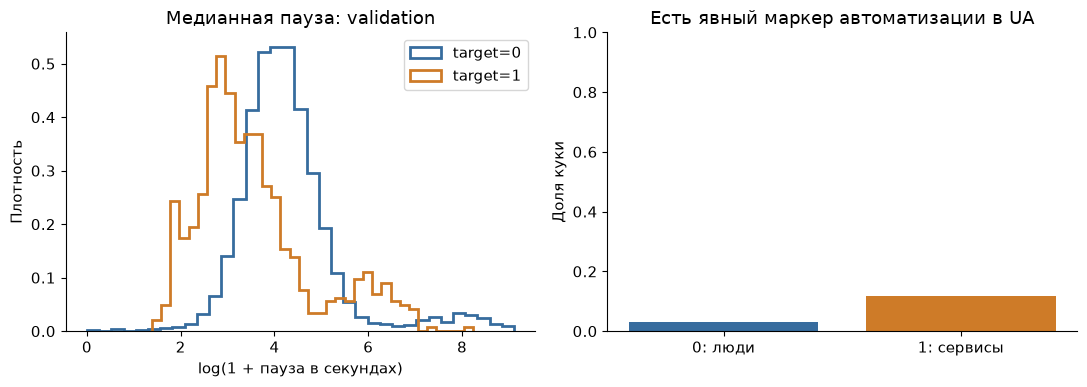

validation                     test                 
                        0.1000  0.5000   0.9000  0.1000  0.5000   0.9000
n_events                3.0000 12.0000  39.0000  3.0000 12.0000  39.0000
item_id_nunique         2.0000  6.0000  21.0000  2.0000  6.0000  21.0000
gap_median             21.0000 59.0000 195.0000 20.0000 56.2500 181.8500
cookie_age_days         1.8351 61.2462 164.3954  1.8251 59.6311 165.3605
ua_automation_share     0.0000  0.0000   0.0000  0.0000  0.0000   0.0000

,validation,test
platform_mode,,
web,0.5332,0.5425
android,0.4152,0.4056
ios,0.0516,0.0519


,count,mean
platform,,
android,62459,0.0000
ios,8316,0.0000
web,89268,0.6049


In [13]:
dev_features = X.loc[dev_ids].join(y)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label in [0, 1]:
    values = dev_features.loc[dev_features.target.eq(label), 'gap_median'].dropna()
    axes[0].hist(np.log1p(values), bins=35, density=True, histtype='step', linewidth=2,
                 color=COLORS[label], label=f'target={label}')
axes[0].set(title='Медианная пауза: validation', xlabel='log(1 + пауза в секундах)', ylabel='Плотность')
axes[0].legend()
ua_table = dev_features.groupby('target')['ua_automation_share'].apply(lambda s: s.gt(0).mean())
axes[1].bar(['0: люди', '1: сервисы'], ua_table, color=[COLORS[0], COLORS[1]])
axes[1].set(title='Есть явный маркер автоматизации в UA', ylabel='Доля куки', ylim=(0, 1))
fig.tight_layout()
plt.show()
shift_columns = ['n_events', 'item_id_nunique', 'gap_median', 'cookie_age_days', 'ua_automation_share']
shift = pd.concat({
    'validation': X.loc[dev_ids, shift_columns].quantile([.1, .5, .9]).T,
    'test': X_test[shift_columns].quantile([.1, .5, .9]).T,
}, axis=1)
display(shift)
platform_shift = pd.concat({
    'validation': X.loc[dev_ids, 'platform_mode'].value_counts(normalize=True),
    'test': X_test['platform_mode'].value_counts(normalize=True),
}, axis=1).fillna(0)
display(platform_shift)
telemetry = eda_events.assign(pointer_known=eda_events[['pointer_x', 'pointer_y']].notna().all(axis=1))
display(telemetry.groupby('platform')['pointer_known'].agg(['count', 'mean']))
assert features['unique_viewed_items_share'].dropna().between(0, 1).all()

## 3. Валидация

Используем три расширяющихся временных фолда. Все обучающие окна заканчиваются до начала validation. Последние три дня train - holdout.

In [13]:
TARGET_RECALL = 0.70


def pr_curve(y_true, score) -> tuple[np.ndarray, np.ndarray]:
    """(precision, recall) в точках на границах групп одинакового score."""
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    if y_true.shape != score.shape:
        raise ValueError("y_true и score разной длины")

    n_pos = int(y_true.sum())
    if n_pos == 0:
        return np.array([]), np.array([])

    order = np.argsort(-score, kind="mergesort")
    y, s = y_true[order], score[order]

    tp = np.cumsum(y)
    k = np.arange(1, len(y) + 1)
    ends = np.r_[s[1:] != s[:-1], True]      # последняя строка каждой группы равных score
    return tp[ends] / k[ends], tp[ends] / n_pos


def precision_at_recall(y_true, score, recall: float = TARGET_RECALL) -> float:
    """Максимальный precision среди порогов с recall >= `recall`."""
    prec, rec = pr_curve(y_true, score)
    if len(prec) == 0:
        return float("nan")
    ok = rec >= recall
    return float(prec[ok].max()) if ok.any() else 0.0

In [ ]:
def temporal_folds(meta, periods):
    """К началу validation должны закончиться окна обучающих куки."""
    indexed = meta.set_index('cookie_id')
    folds = []
    for start, end in periods:
        start, end = pd.Timestamp(start), pd.Timestamp(end)
        fit = indexed.index[indexed['window_end_ts'].le(start)]
        valid = indexed.index[indexed['window_start_ts'].ge(start) & indexed['window_end_ts'].le(end)]
        assert len(fit) and len(valid)
        assert set(fit).isdisjoint(valid)
        assert indexed.loc[fit, 'window_end_ts'].max() <= indexed.loc[valid, 'window_start_ts'].min()
        folds.append((fit, valid))
    return folds


def paired_cv_interval(y, first, second, folds, repetitions=1500, seed=42):
    """Условный bootstrap разности средних, парный и по классам внутри фолда.

    Фиксирует модели и даты; не учитывает связь куки и выбор модели.
    """
    rng = np.random.default_rng(seed)
    differences = np.zeros(repetitions)
    for _, valid in folds:
        labels = y.loc[valid].to_numpy()
        a, b = first.loc[valid].to_numpy(), second.loc[valid].to_numpy()
        positive, negative = np.flatnonzero(labels == 1), np.flatnonzero(labels == 0)
        for iteration in range(repetitions):
            sampled = np.r_[rng.choice(positive, len(positive)), rng.choice(negative, len(negative))]
            differences[iteration] += (precision_at_recall(labels[sampled], a[sampled])
                                       - precision_at_recall(labels[sampled], b[sampled])) / len(folds)
    return np.quantile(differences, [.025, .975])


def segment_metrics(frame, column, threshold):
    """Единый порог из validation, отдельно от оптимума внутри сегмента."""
    rows = []
    for segment, group in frame.groupby(column, dropna=False):
        tn, fp, fn, tp = confusion_matrix(group['target'], group['score'].ge(threshold), labels=[0, 1]).ravel()
        rows.append({
            'segment': segment, 'n': len(group), 'positive': int(group['target'].sum()),
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'precision_fixed': tp / (tp + fp) if tp + fp else np.nan,
            'recall_fixed': tp / (tp + fn) if tp + fn else np.nan,
            'P@R>=0.70_segment': precision_at_recall(group['target'], group['score']) if tp + fn else np.nan,
        })
    return pd.DataFrame(rows)

In [ ]:
periods = [('2026-04-10', '2026-04-12'), ('2026-04-12', '2026-04-14'),
           ('2026-04-14', '2026-04-17')]
folds = temporal_folds(validation, periods)
fold_description = []
for (fit_ids, valid_ids), (start, end) in zip(folds, periods):
    assert set(valid_ids).isdisjoint(holdout_ids)
    fold_description.append({'valid_start': start, 'valid_end_exclusive': end,
                             'train_n': len(fit_ids), 'valid_n': len(valid_ids),
                             'positive_n': int(y.loc[valid_ids].sum())})
display(pd.DataFrame(fold_description))
split = pd.DataFrame({'date': dates, 'target': y})
split['role'] = np.where(dates.ge(HOLDOUT_START), 'holdout', 'validation')
for number, (_, ids) in enumerate(folds, 1):
    split.loc[ids, 'validation_fold'] = number

,valid_start,valid_end_exclusive,train_n,valid_n,positive_n
0,2026-04-10,2026-04-12,3305,1808,161
1,2026-04-12,2026-04-14,5113,1660,120
2,2026-04-14,2026-04-17,6773,2367,195


## 4. Базовые модели

In [16]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler





class FrequencyEncoder(TransformerMixin, BaseEstimator):
    """Частоты категорий только на обучающей части; новые категории получают 0."""

    def fit(self, X, y=None):
        self.frequencies_ = {c: X[c].value_counts(normalize=True) for c in X}
        return self

    def transform(self, X):
        return np.column_stack([
            X[c].map(self.frequencies_[c]).fillna(0).to_numpy() for c in X
        ])


def metrics(y, prediction):
    return {
        'P@R>=0.70': precision_at_recall(y, prediction),
        'PR-AUC (AP)': average_precision_score(y, prediction),
        'ROC-AUC': roc_auc_score(y, prediction),
    }


def select_columns(X, feature_set):
    basic = ['n_events', 'item_id_nunique']
    if feature_set == 'basic':
        return basic
    if feature_set == 'numeric':
        return list(X.select_dtypes('number').columns)
    if feature_set == 'behavior':
        # Абляция: можно ли обойтись без возраста и технических отпечатков?
        return [c for c in X if not (
            c.startswith(('ua_', 'user_agent_', 'platform_', 'browser_', 'pointer_', 'web_pointer_'))
            or c == 'cookie_age_days'
        )]
    return list(X.columns)


def build_model(spec, X, seed=SEED):
    """X содержит только обучающую часть: отбор колонок также не видит validation."""
    columns = select_columns(X, spec.get('features', 'full'))
    if not spec.get('view_share', False):
        columns = [c for c in columns if c != 'unique_viewed_items_share']
    if spec.get('no_pointer', False):
        columns = [c for c in columns if not c.startswith(('pointer_', 'web_pointer_'))]
    if spec.get('simplify', False):
        columns = nonredundant_columns(X[columns])
    numeric = list(X[columns].select_dtypes('number').columns)
    categorical = [c for c in columns if c not in numeric]
    kind = spec['kind']
    if kind == 'catboost':
        model = CatBoostClassifier(
            iterations=spec.get('iterations', 450), depth=spec.get('depth', 5), learning_rate=spec.get('learning_rate', .04),
            l2_leaf_reg=spec.get('l2_leaf_reg', 5), class_weights=spec.get('class_weights'),
            loss_function='Logloss', random_seed=seed,
            random_strength=spec.get('random_strength', 1), rsm=spec.get('rsm', 1),
            cat_features=categorical, verbose=False, allow_writing_files=False,
            thread_count=4,
        )
        return model, columns

    numeric_steps = [('impute', SimpleImputer(strategy='constant' if spec.get('sentinel') else 'median',
        fill_value=-1, add_indicator=True, keep_empty_features=True))]
    if kind == 'logistic':
        if spec.get('log', True):
            numeric_steps.append(('log', FunctionTransformer(np.log1p)))
        numeric_steps.append(('scale', StandardScaler()))
    category_encoder = (
        FrequencyEncoder() if spec.get('encoding') == 'frequency'
        else OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False)
    )
    preprocess = ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), numeric),
        ('category', category_encoder, categorical),
    ])
    if kind == 'logistic':
        l1_ratio = spec.get('l1_ratio', 0)
        model = LogisticRegression(
            C=spec.get('C', 1), l1_ratio=l1_ratio,
            solver='saga' if 0 < l1_ratio < 1 else 'liblinear',
            class_weight=spec.get('class_weight'), max_iter=4000,
            random_state=seed,
        )
    elif kind == 'forest':
        model = RandomForestClassifier(
            n_estimators=300, min_samples_leaf=3, max_features=0.7,
            random_state=seed, n_jobs=4,
        )
    elif kind == 'histboost':
        model = HistGradientBoostingClassifier(
            max_iter=spec.get('iterations', 250), learning_rate=.05, max_leaf_nodes=spec.get('max_leaf_nodes', 15),
            l2_regularization=spec.get('l2_leaf_reg', 5), early_stopping=False, random_state=seed,
        )
    else:
        raise ValueError(f'Unknown model: {kind}')
    return Pipeline([('prepare', preprocess), ('model', model)]), columns


def nonredundant_columns(X):
    """Константы, точные копии и три проверяемых дополнения долей на train."""
    kept = []
    complements = {
        'search_query_missing_share': 'search_results_view_share',
        'search_page_missing_share': 'search_results_view_share',
        'ua_mobile_share': 'platform_web_share',
    }
    for column in X:
        if X[column].nunique(dropna=False) <= 1:
            continue
        other = complements.get(column)
        if other in X and (X[column] + X[other]).eq(1).all():
            continue
        if any(X[column].equals(X[previous]) for previous in kept):
            continue
        kept.append(column)
    return kept


def heuristic(spec, X, prevalence):
    if spec['kind'] == 'constant':
        return np.full(len(X), prevalence)
    if spec['kind'] == 'activity':
        return X['n_events'].to_numpy() / (X['n_events'].to_numpy() + 20)
    if spec['kind'] == 'ua_rule':
        return X['ua_automation_share'].fillna(0).to_numpy()
    raise ValueError(spec['kind'])


def evaluate_experiments(specs, X, y, folds, variants=None):
    """Одинаковые временные фолды для всех экспериментов."""
    rows, predictions = [], {}
    for name, spec in specs.items():
        current_X = (variants or {}).get(spec.get('data'), X)
        prediction = pd.Series(np.nan, index=X.index, dtype=float)
        for fold, (fit_ids, valid_ids) in enumerate(folds, start=1):
            started = time.perf_counter()
            if spec['kind'] in ['constant', 'activity', 'ua_rule']:
                score = heuristic(spec, X.loc[valid_ids], y.loc[fit_ids].mean())
            else:
                model, columns = build_model(spec, current_X.loc[fit_ids])
                model.fit(current_X.loc[fit_ids, columns], y.loc[fit_ids])
                score = model.predict_proba(current_X.loc[valid_ids, columns])[:, 1]
            prediction.loc[valid_ids] = score
            rows.append({
                'experiment': name, 'fold': fold, **metrics(y.loc[valid_ids], score),
                'seconds': time.perf_counter() - started,
            })
        predictions[name] = prediction
        mean_score = np.mean([r['P@R>=0.70'] for r in rows if r['experiment'] == name])
    return pd.DataFrame(rows), predictions

In [ ]:
experiments = {
    '01 Constant': {'kind': 'constant'},
    '02 Activity rule': {'kind': 'activity'},
    '03 UA rule': {'kind': 'ua_rule'},
    '04 LR basic raw': {'kind': 'logistic', 'features': 'basic', 'log': False},
    '05 LR basic log': {'kind': 'logistic', 'features': 'basic'},
    '06 LR numeric': {'kind': 'logistic', 'features': 'numeric'},
    '07 LR OHE L2 C=0.1': {'kind': 'logistic', 'C': .1},
    '08 LR OHE L2 C=1': {'kind': 'logistic', 'C': 1},
    '09 LR OHE L2 C=10': {'kind': 'logistic', 'C': 10},
    '10 LR OHE L1 C=0.1': {'kind': 'logistic', 'C': .1, 'l1_ratio': 1},
    '11 LR Elastic Net': {'kind': 'logistic', 'C': .1, 'l1_ratio': .5},
    '12 LR balanced': {'kind': 'logistic', 'C': .1, 'class_weight': 'balanced'},
    '13 LR frequency': {'kind': 'logistic', 'C': .1, 'encoding': 'frequency'},
    '14 Forest basic': {'kind': 'forest', 'features': 'basic'},
    '15 Forest full': {'kind': 'forest'},
    '16 HistGradientBoosting': {'kind': 'histboost'},
    '17 CatBoost behavior': {'kind': 'catboost', 'features': 'behavior', 'depth': 5},
    '18 CatBoost depth=4': {'kind': 'catboost', 'depth': 4},
    '19 CatBoost depth=6': {'kind': 'catboost', 'depth': 6},
    '20 HGB viewed items': {'kind': 'histboost', 'view_share': True},
    '21 HGB simplified': {'kind': 'histboost', 'view_share': True, 'simplify': True},
    '22 HGB no coordinates': {'kind': 'histboost', 'view_share': True, 'no_pointer': True},
    '23 HGB behavior': {'kind': 'histboost', 'view_share': True, 'features': 'behavior'},
    '24 CatBoost depth=5': {'kind': 'catboost', 'depth': 5},
    '25 HGB keep duplicates': {'kind': 'histboost', 'view_share': True, 'data': 'keep_duplicates'},
})
# Альтернатива меняет только политику дублей, но соблюдает те же окна.
retained_features = make_features(prepare_events(events, meta, drop_duplicates=False), meta)
variants = {'keep_duplicates': retained_features.loc[train['cookie_id']]}

fold_results, cv_predictions = evaluate_experiments(experiments, X.loc[dev_ids], y.loc[dev_ids], folds, variants)
BASELINE = '24 CatBoost depth=5'

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

new_specs = {
    '26 CatBoost transitions': {'kind': 'catboost', 'depth': 5, 'table': 'sequence'},
    '27 CatBoost timing': {'kind': 'catboost', 'depth': 5, 'table': 'temporal'},
    '28 CatBoost item paths': {'kind': 'catboost', 'depth': 5, 'table': 'items', 'view_share': True},
    '29 CatBoost pointer motion': {'kind': 'catboost', 'depth': 5, 'table': 'pointer'},
    '30 TF-IDF event ngrams LR': {'kind': 'text', 'table': 'documents'},
    '31 CatBoost hard negatives': {'kind': 'hard', 'depth': 5},
}
all_specs = {BASELINE: {'kind': 'catboost', 'depth': 5, 'table': 'base'}, **new_specs}
GROUP_NAMES = list(new_specs)[:4]
train_meta = train.set_index('cookie_id')
mining_cache = {}
mining_details = []

def threshold_at_recall(labels, score):
    precision, recall, thresholds = precision_recall_curve(labels, score)
    eligible = np.flatnonzero(recall[:-1] >= .7)
    return float(thresholds[eligible[np.argmax(precision[:-1][eligible])]])

def fit_plain(spec, ids, seed=SEED, weights=None):
    if spec['kind'] == 'text':
        model = Pipeline([
            ('tfidf', TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False,
                                      ngram_range=(1, 3), min_df=3, max_features=20000, sublinear_tf=True)),
            ('model', LogisticRegression(C=1, l1_ratio=0, solver='liblinear', max_iter=4000, random_state=seed)),
        ])
        model.fit(documents.loc[ids], y.loc[ids])
        return {'model': model, 'table': 'documents', 'columns': None}
    table_name = spec.get('table', 'base')
    table = feature_tables[table_name]
    model, columns = build_model(spec, table.loc[ids], seed=seed)
    if weights is None:
        model.fit(table.loc[ids, columns], y.loc[ids])
    else:
        model.fit(table.loc[ids, columns], y.loc[ids], sample_weight=weights)
    return {'model': model, 'table': table_name, 'columns': columns}

def predict_bundle(bundle, ids):
    values = documents.loc[ids] if bundle['table'] == 'documents' else feature_tables[bundle['table']].loc[ids, bundle['columns']]
    score = bundle['model'].predict_proba(values)[:, 1]
    assert np.isfinite(score).all() and ((score >= 0) & (score <= 1)).all()
    return score

def mine_training_only(fit_ids):
    key = tuple(fit_ids)
    if key in mining_cache:
        return mining_cache[key]
    local = train_meta.loc[fit_ids].reset_index()
    days = sorted(local['window_start_ts'].unique())
    warmup = max(2, len(days) // 2)
    blocks = np.array_split(np.array(days[warmup:]), 2)
    periods = [(pd.Timestamp(block[0]), pd.Timestamp(block[-1]) + pd.Timedelta(days=1)) for block in blocks if len(block)]
    inner_folds = temporal_folds(local, periods)
    records, masks = [], {}
    for name in GROUP_NAMES:
        hard = pd.Series(False, index=fit_ids)
        for number, (inner_fit, inner_valid) in enumerate(inner_folds, 1):
            assert set(inner_fit).issubset(fit_ids) and set(inner_valid).issubset(fit_ids)
            assert set(inner_fit).isdisjoint(inner_valid)
            bundle = fit_plain(new_specs[name], inner_fit, seed=SEED)
            score = predict_bundle(bundle, inner_valid)
            threshold = threshold_at_recall(y.loc[inner_valid], score)
            hard.loc[inner_valid] = (y.loc[inner_valid].to_numpy() == 0) & (score >= threshold)
            records.append({'group': name, 'inner_fold': number, **metrics(y.loc[inner_valid], score)})
        masks[name] = hard
    inner_table = pd.DataFrame(records).groupby('group')[['P@R>=0.70', 'PR-AUC (AP)']].mean()
    chosen = inner_table.sort_values(['P@R>=0.70', 'PR-AUC (AP)'], ascending=False).index[0]
    weights = 1. + masks[chosen].astype(float)
    assert weights.index.equals(pd.Index(fit_ids))
    assert weights.loc[y.loc[fit_ids].eq(1)].eq(1).all()
    result = {'group': chosen, 'weights': weights, 'inner_table': inner_table,
              'hard_negatives': int(masks[chosen].sum()), 'inner_folds': inner_folds}
    mining_cache[key] = result
    return result

def fit_advanced(name, fit_ids, seed=SEED):
    spec = all_specs[name]
    if spec['kind'] != 'hard':
        return fit_plain(spec, fit_ids, seed), None
    mining = mine_training_only(fit_ids)
    bundle = fit_plain(new_specs[mining['group']], fit_ids, seed, mining['weights'])
    return bundle, mining

def evaluate_new(names, evaluation_folds, seed=SEED, control=False):
    rows, predictions, details = [], {}, []
    for name in names:
        prediction = pd.Series(np.nan, index=train['cookie_id'], dtype=float)
        for number, (fit_ids, valid_ids) in enumerate(evaluation_folds, 1):
            assert set(fit_ids).isdisjoint(valid_ids)
            started = time.perf_counter()
            bundle, mining = fit_advanced(name, fit_ids, seed)
            score = predict_bundle(bundle, valid_ids)
            prediction.loc[valid_ids] = score
            result = {'experiment': name, 'fold': number, 'seed': seed,
                      **metrics(y.loc[valid_ids], score), 'seconds': time.perf_counter() - started}
            rows.append(result)
            if mining is not None:
                detail = {'fold': number, 'seed': seed, 'chosen_group': mining['group'],
                          'train_n': len(fit_ids), 'hard_negatives': mining['hard_negatives']}
                if control:
                    plain = fit_plain(new_specs[mining['group']], fit_ids, seed)
                    plain_score = predict_bundle(plain, valid_ids)
                    detail.update({'unweighted_P': precision_at_recall(y.loc[valid_ids], plain_score),
                                   'weighted_P': result['P@R>=0.70']})
                details.append(detail)
        predictions[name] = prediction
    return pd.DataFrame(rows), predictions, pd.DataFrame(details)

new_results, new_predictions = [], {}

In [19]:
def duplicate_features(raw_events, cookie_meta):
    """Полные повторы исходных строк внутри окна, до нормализации platform."""
    raw_columns = list(raw_events.columns)
    data = raw_events.copy()
    data['event_ts'] = pd.to_datetime(data['event_ts'], format='mixed', errors='coerce')
    data = data.merge(cookie_meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
                      on='cookie_id', how='left', validate='many_to_one')
    data = data.loc[data.event_ts.ge(data.window_start_ts) & data.event_ts.lt(data.window_end_ts)]
    result = pd.DataFrame(index=pd.Index(cookie_meta['cookie_id'], name='cookie_id'))
    names = ['dup_extra_count', 'dup_extra_share', 'dup_group_count',
             'dup_repeated_row_share', 'dup_max_multiplicity']
    names += ['dup_' + event + '_extra_share' for event in event_names]
    if data.empty:
        return pd.DataFrame(0., index=result.index, columns=names)
    # dropna=False: совпадающие пропуски не исключают строку из подсчета.
    groups = data.groupby(raw_columns, dropna=False, sort=False).size().rename('multiplicity').reset_index()
    groups['extra'] = groups['multiplicity'] - 1
    counts = data.groupby('cookie_id').size()
    repeated = groups.loc[groups.multiplicity.gt(1)]
    result['dup_extra_count'] = groups.groupby('cookie_id')['extra'].sum()
    result['dup_extra_share'] = result['dup_extra_count'] / counts
    result['dup_group_count'] = repeated.groupby('cookie_id').size()
    result['dup_repeated_row_share'] = repeated.groupby('cookie_id')['multiplicity'].sum() / counts
    result['dup_max_multiplicity'] = groups.groupby('cookie_id')['multiplicity'].max()
    for event in event_names:
        selected = groups.loc[groups.event_name.eq(event)]
        extra = selected.groupby('cookie_id')['extra'].sum()
        total = selected.groupby('cookie_id')['multiplicity'].sum()
        result['dup_' + event + '_extra_share'] = extra / total
    # При отсутствии событий соответствующего типа повторов тоже нет.
    return result.reindex(columns=names).fillna(0.).astype(float)



duplicate_stats = duplicate_features(events, meta)
assert duplicate_stats.dup_extra_count.sum() == quality['duplicates_inside_window']
compact_duplicate_columns = ['dup_extra_count', 'dup_extra_share', 'dup_max_multiplicity']
feature_tables['pointer_duplicates'] = feature_tables['pointer'].join(duplicate_stats)
feature_tables['pointer_duplicate_core'] = feature_tables['pointer'].join(duplicate_stats[compact_duplicate_columns])
position_columns = [f'motion_{axis}_{stat}' for axis in ['x', 'y']
                    for stat in ['mean', 'q10', 'q50', 'q90']]
feature_tables['pointer_no_positions'] = feature_tables['pointer'].drop(columns=position_columns)
compact_columns = ['motion_pair_entropy', 'motion_mode_pair_share',
                   'motion_zero_displacement_share', 'motion_observed_links']
feature_tables['pointer_compact'] = features.join(advanced['pointer'][compact_columns])
refinement_specs = {
    '32 CatBoost no absolute positions': {'kind': 'catboost', 'depth': 5, 'table': 'pointer_no_positions'},
    '33 CatBoost stronger regularization': {'kind': 'catboost', 'depth': 4, 'l2_leaf_reg': 15, 'table': 'pointer'},
    '34 CatBoost positive weight 2': {'kind': 'catboost', 'depth': 5, 'class_weights': [1., 2.], 'table': 'pointer'},
    '35 HGB pointer features': {'kind': 'histboost', 'table': 'pointer'},
    '36 CatBoost 900 trees': {'kind': 'catboost', 'depth': 5, 'iterations': 900, 'table': 'pointer'},
    '37 CatBoost compact pointer': {'kind': 'catboost', 'depth': 5, 'table': 'pointer_compact'},
}
all_specs.update(refinement_specs)

all_specs.update({
 '38 CatBoost duplicate features': {'kind': 'catboost', 'table': 'pointer_duplicates'},
 '39 CatBoost compact duplicates': {'kind': 'catboost', 'table': 'pointer_duplicate_core'},
})

In [20]:
history_rows, history_predictions, mining_summary = evaluate_new(
    [name for name in all_specs if name != BASELINE], folds, control=True)
history_results = pd.concat([fold_results.assign(seed=SEED), history_rows], ignore_index=True)
history_summary = history_results.groupby('experiment').agg(
    P_mean=('P@R>=0.70', 'mean'), P_min=('P@R>=0.70', 'min'),
    AP=('PR-AUC (AP)', 'mean'), ROC_AUC=('ROC-AUC', 'mean'))
display(history_summary.sort_values('P_mean', ascending=False).round(4))
display(mining_summary)

,P_mean,P_min,AP,ROC_AUC
experiment,,,,
29 CatBoost pointer motion,0.7698,0.7326,0.7760,0.9311
36 CatBoost 900 trees,0.7485,0.7211,0.7769,0.9302
38 CatBoost duplicate features,0.7425,0.7211,0.7766,0.9299
31 CatBoost hard negatives,0.7398,0.7211,0.7769,0.9296
35 HGB pointer features,0.7349,0.7005,0.7658,0.9233
34 CatBoost positive weight 2,0.7314,0.6807,0.7768,0.9319
24 CatBoost depth=5,0.7242,0.6807,0.7718,0.9268
32 CatBoost no absolute positions,0.7235,0.6847,0.7705,0.9276
39 CatBoost compact duplicates,0.7201,0.6384,0.7722,0.9295


,fold,seed,chosen_group,train_n,hard_negatives,unweighted_P,weighted_P
0,1,42,29 CatBoost pointer motion,3305,28,0.7533,0.7483
1,2,42,29 CatBoost pointer motion,5113,61,0.8235,0.7500
2,3,42,29 CatBoost pointer motion,6773,55,0.7326,0.7211


## 5. Устойчивость, пропуски и ансамбли

Проверяем ограниченный набор гипотез на трех seed.

Optuna не используется для подбора гиперпараметров во избежание переобучения на небольших объемах данных.

In [21]:
def conditional_missing_features(data, index):
    out = pd.DataFrame(index=index)
    groups = {
        'search': data.event_name.eq('search_results_view'),
        'web': data.platform.eq('web'),
    }
    for name, mask in groups.items():
        subset = data.loc[mask]
        count = subset.groupby('cookie_id').size().reindex(index, fill_value=0)
        out[name + '_not_applicable'] = count.eq(0).astype(int)
        columns = ['search_query', 'search_page'] if name == 'search' else ['pointer_x', 'pointer_y']
        for column in columns:
            out[name + '_' + column + '_missing'] = (
                subset[column].isna().groupby(subset.cookie_id).mean().reindex(index))
    return out

conditional_missing = conditional_missing_features(clean_events, features.index)
feature_tables['conditional'] = feature_tables['pointer_duplicate_core'].join(conditional_missing)
BASE = 'CB duplicates'
review_specs = {
    BASE: {'kind': 'catboost', 'table': 'pointer_duplicate_core'},
    'CB no duplicates': {'kind': 'catboost', 'table': 'pointer'},
    'CB conditional missing': {'kind': 'catboost', 'table': 'conditional'},
    'CB sentinel -1': {'kind': 'catboost', 'table': 'pointer_duplicate_core', 'sentinel': True},
    'CB regularized': {'kind': 'catboost', 'table': 'pointer_duplicate_core',
                       'depth': 4, 'l2_leaf_reg': 15, 'random_strength': 2, 'rsm': .8},
    'CB top 60': {'kind': 'catboost', 'table': 'pointer_duplicate_core', 'top_k': 60},
    'CB log tails': {'kind': 'catboost', 'table': 'pointer_duplicate_core', 'log_tails': True},
    'CB platform weights': {'kind': 'catboost', 'table': 'pointer_duplicate_core', 'platform_weights': True},
    'HGB duplicates': {'kind': 'histboost', 'table': 'pointer_duplicate_core'},
    'HGB sentinel -1': {'kind': 'histboost', 'table': 'pointer_duplicate_core', 'sentinel': True},
    'HGB regularized': {'kind': 'histboost', 'table': 'pointer_duplicate_core',
                        'max_leaf_nodes': 7, 'l2_leaf_reg': 15},
    'HGB pointer': {'kind': 'histboost', 'table': 'pointer'},
    'LR balanced': {'kind': 'logistic', 'table': 'base', 'C': .1, 'class_weight': 'balanced'},
}
REVIEW_SEEDS = [42, 137, 2026]
fit_cache = {}


def fit_review(name, ids, seed=42):
    spec = review_specs[name]
    key = (name, tuple(ids), seed)
    if key in fit_cache:
        return fit_cache[key]
    table = feature_tables[spec['table']]
    fit = table.loc[ids].copy()
    log_columns = []
    if spec.get('log_tails'):
        numeric = fit.select_dtypes('number')
        log_columns = list(numeric.columns[numeric.min().ge(0) & numeric.skew().gt(2)])
        fit[log_columns] = np.log1p(fit[log_columns])
    if spec.get('sentinel') and spec['kind'] == 'catboost':
        columns = fit.select_dtypes('number').columns
        fit[columns] = fit[columns].fillna(-1)
    if spec.get('top_k'):
        reference = fit_review(BASE, ids, seed)
        importance = pd.Series(reference['model'].feature_importances_, index=reference['columns'])
        available = nonredundant_columns(fit[reference['columns']])
        protected = compact_duplicate_columns
        ranked = importance.loc[[c for c in available if c not in protected]].sort_values(ascending=False)
        chosen = protected + ranked.head(spec['top_k'] - len(protected)).index.tolist()
        fit = fit[[c for c in fit if c in chosen]]
    model, columns = build_model(spec, fit, seed)
    weights = None
    if spec.get('platform_weights'):
        platform = fit['platform_mode']
        frequency = platform.value_counts(normalize=True)
        weights = platform.map((1 / (len(frequency) * frequency)).clip(.5, 3))
        weights = weights / weights.mean()
    if weights is None:
        model.fit(fit[columns], y.loc[ids])
    else:
        model.fit(fit[columns], y.loc[ids], sample_weight=weights)
    bundle = dict(model=model, columns=columns, log_columns=log_columns, spec=spec)
    fit_cache[key] = bundle
    return bundle


def review_predict(bundle, ids):
    values = feature_tables[bundle['spec']['table']].loc[ids, bundle['columns']].copy()
    logs = bundle['log_columns']
    values[logs] = np.log1p(values[logs])
    if bundle['spec'].get('sentinel') and bundle['spec']['kind'] == 'catboost':
        numeric = values.select_dtypes('number').columns
        values[numeric] = values[numeric].fillna(-1)
    return bundle['model'].predict_proba(values)[:, 1]


def seed_average(name, fit_ids, predict_ids):
    return np.mean([review_predict(fit_review(name, fit_ids, seed), predict_ids)
                    for seed in REVIEW_SEEDS], axis=0)


platform = features['platform_mode']
fold_platform = []
for number, (fit_ids, valid_ids) in enumerate(folds, 1):
    for role, ids in [('train', fit_ids), ('valid', valid_ids)]:
        group = pd.DataFrame({'platform': platform.loc[ids], 'target': y.loc[ids]})
        composition = group.groupby('platform').target.agg(n='size', positive='sum', prevalence='mean')
        fold_platform.append(composition.assign(fold=number, role=role).reset_index())
display(pd.concat(fold_platform).set_index(['fold', 'role', 'platform']))
tails = feature_tables['pointer_duplicate_core'].loc[dev_ids].select_dtypes('number')
tail_summary = tails.quantile([.5, .95, .99, 1]).T
# Описательная таблица; при fit список log-признаков определяется заново на train.
tail_summary['skew'] = tails.skew()
display(tail_summary.sort_values('skew', ascending=False).head(12).round(3))
display(conditional_missing.loc[dev_ids].join(y).groupby('target').mean().round(4))

n  positive  prevalence
fold role  platform                            
1    train android   1302        90      0.0691
           ios        186         9      0.0484
           web       1817       164      0.0903
     valid android    739        45      0.0609
           ios        107         6      0.0561
           web        962       110      0.1143
2    train android   2041       135      0.0661
           ios        293        15      0.0512
           web       2779       274      0.0986
     valid android    743        37      0.0498
           ios         62         3      0.0484
           web        855        80      0.0936
3    train android   2784       172      0.0618
           ios        355        18      0.0507
           web       3634       354      0.0974
     valid android   1011        59      0.0584
           ios        117         4      0.0342
           web       1239       132      0.1065

,0.5000,0.9500,0.9900,1.0000,skew
motion_displacement_per_second_q10,4.8170,23.2720,93.7890,1185.1420,18.8350
gap_zero_share,0.0000,0.0410,0.1430,1.0000,13.5420
gap_min,7.0000,92.0000,956.6300,9005.0000,12.6350
session_gap_min,7.0000,79.0000,264.4400,1758.0000,12.5310
motion_displacement_per_second_q50,14.8930,55.3410,195.1500,1185.1420,12.3910
contact_message_sent_share,0.0000,0.0560,0.1250,1.0000,9.0830
session_gap_median,46.5000,171.0000,452.1400,1758.0000,7.7420
login_share,0.0000,0.1110,0.2500,1.0000,6.8370
motion_displacement_per_second_mean,28.5660,141.2750,316.0790,1185.1420,6.4810
gap_median,59.0000,648.8250,4444.1650,9005.0000,6.4320


,search_not_applicable,search_search_query_missing,search_search_page_missing,web_not_applicable,web_pointer_x_missing,web_pointer_y_missing
target,,,,,,
0,0.0856,0.0000,0.0000,0.4778,0.3220,0.3220
1,0.0433,0.0000,0.0000,0.3424,0.5972,0.5972


In [2]:
review_rows, review_predictions = [], {}
for name in review_specs:
    for seed in REVIEW_SEEDS:
        oof = pd.Series(np.nan, index=y.index)
        for number, (fit_ids, valid_ids) in enumerate(folds, 1):
            bundle = fit_review(name, fit_ids, seed)
            score = review_predict(bundle, valid_ids)
            train_score = review_predict(bundle, fit_ids)
            oof.loc[valid_ids] = score
            review_rows.append({'model': name, 'seed': seed, 'fold': number,
                **metrics(y.loc[valid_ids], score),
                'train_P': precision_at_recall(y.loc[fit_ids], train_score),
                'train_AP': average_precision_score(y.loc[fit_ids], train_score),
                'n_features': len(bundle['columns'])})
        review_predictions[name, seed] = oof
review_results = pd.DataFrame(review_rows)
seed_results = review_results.groupby(['model', 'seed'])['P@R>=0.70'].mean().unstack()
seed_results['mean'] = seed_results.mean(axis=1)
seed_results['seed_range'] = seed_results[REVIEW_SEEDS].max(axis=1) - seed_results[REVIEW_SEEDS].min(axis=1)
ap_by_seed = review_results.groupby(['model', 'seed'])['PR-AUC (AP)'].mean().unstack()
seed_results['AP_range'] = ap_by_seed.max(axis=1) - ap_by_seed.min(axis=1)
seed_results['delta'] = seed_results['mean'] - seed_results.loc[BASE, 'mean']
display(seed_results.sort_values('mean', ascending=False).round(4))
overfit = review_results.groupby('model').agg(
    train_P=('train_P', 'mean'), valid_P=('P@R>=0.70', 'mean'),
    train_AP=('train_AP', 'mean'), valid_AP=('PR-AUC (AP)', 'mean'), features=('n_features', 'mean'))
overfit['AP_gap'] = overfit.train_AP - overfit.valid_AP
display(overfit.round(4))

seed,42,137,2026,mean,seed_range,AP_range,delta
model,,,,,,,
HGB duplicates,0.7384,0.7384,0.7384,0.7384,0.0000,0.0000,0.0078
CB no duplicates,0.7698,0.7006,0.7416,0.7373,0.0693,0.0066,0.0067
HGB pointer,0.7349,0.7349,0.7349,0.7349,0.0000,0.0000,0.0043
CB duplicates,0.7201,0.7379,0.7341,0.7307,0.0178,0.0036,0.0000
CB log tails,0.7201,0.7379,0.7341,0.7307,0.0178,0.0036,0.0000
CB top 60,0.7242,0.7236,0.7366,0.7281,0.0130,0.0037,-0.0025
CB platform weights,0.7162,0.7391,0.7174,0.7242,0.0229,0.0018,-0.0064
CB conditional missing,0.7145,0.7355,0.7199,0.7233,0.0210,0.0051,-0.0074
HGB sentinel -1,0.7172,0.7172,0.7172,0.7172,0.0000,0.0000,-0.0134


,train_P,valid_P,train_AP,valid_AP,features,AP_gap
model,,,,,,
CB conditional missing,0.9900,0.7233,0.9504,0.7743,134.0000,0.1761
CB duplicates,0.9852,0.7307,0.9481,0.7723,128.0000,0.1758
CB log tails,0.9852,0.7307,0.9481,0.7723,128.0000,0.1758
CB no duplicates,0.9888,0.7373,0.9498,0.7732,125.0000,0.1767
CB platform weights,0.9778,0.7242,0.9423,0.7700,128.0000,0.1723
CB regularized,0.9000,0.7108,0.8804,0.7705,128.0000,0.1100
CB sentinel -1,0.9881,0.7093,0.9493,0.7702,128.0000,0.1791
CB top 60,0.9914,0.7281,0.9532,0.7750,60.0000,0.1783
HGB duplicates,1.0000,0.7384,0.9923,0.7672,128.0000,0.2251


,P_mean,P_min,AP,ROC_AUC
model,,,,
CB no duplicates,0.7496,0.7150,0.7754,0.9312
CB duplicates,0.7490,0.7107,0.7743,0.9314
CB log tails,0.7490,0.7107,0.7743,0.9314
HGB duplicates,0.7384,0.7135,0.7672,0.9239
HGB pointer,0.7349,0.7005,0.7658,0.9233
CB platform weights,0.7320,0.6766,0.7722,0.9283
CB top 60,0.7307,0.6933,0.7786,0.9314
CB conditional missing,0.7299,0.6807,0.7766,0.9305
CB regularized,0.7234,0.6848,0.7721,0.9304


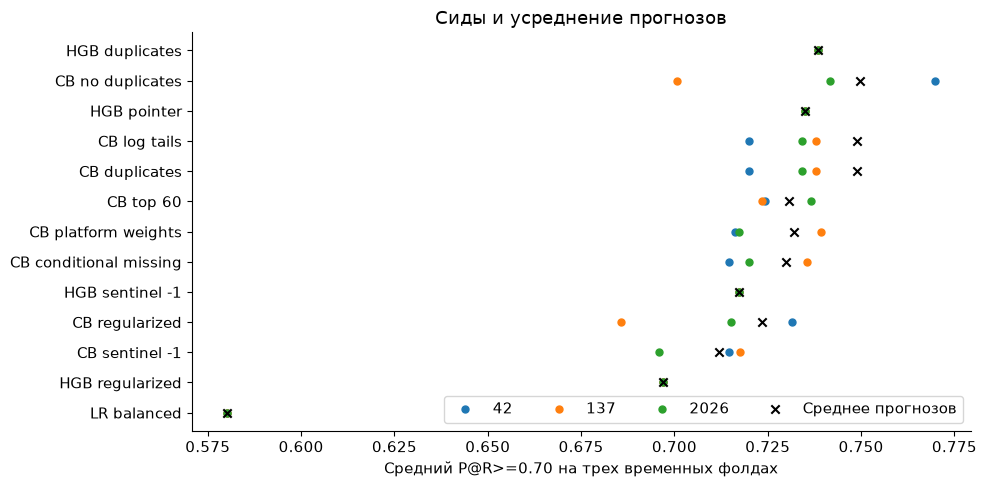

In [23]:
bag_predictions = {name: pd.concat([review_predictions[name, seed] for seed in REVIEW_SEEDS], axis=1).mean(axis=1)
                   for name in review_specs}
bag_rows = []
for name, score in bag_predictions.items():
    for number, (_, ids) in enumerate(folds, 1):
        bag_rows.append({'model': name, 'fold': number, **metrics(y.loc[ids], score.loc[ids])})
bag_results = pd.DataFrame(bag_rows)
bag_summary = bag_results.groupby('model').agg(P_mean=('P@R>=0.70', 'mean'),
    P_min=('P@R>=0.70', 'min'), AP=('PR-AUC (AP)', 'mean'), ROC_AUC=('ROC-AUC', 'mean'))
display(bag_summary.sort_values('P_mean', ascending=False).round(4))
fig, ax = plt.subplots(figsize=(10, 5))
ordered = seed_results.sort_values('mean')
for seed in REVIEW_SEEDS:
    ax.scatter(ordered[seed], ordered.index, label=str(seed), s=25)
ax.scatter(bag_summary.loc[ordered.index, 'P_mean'], ordered.index, marker='x', color='black', label='Среднее прогнозов')
ax.set(xlabel='Средний P@R>=0.70 на трех временных фолдах', title='Сиды и усреднение прогнозов')
ax.legend(ncol=4, loc='lower right')
fig.tight_layout()
plt.show()

### Калибровка и подбор коэффициентов

Заранее фиксируем четыре компонента: CatBoost с тремя признаками дублей, CatBoost без них, HGB с движениями указателя и лучшую прежнюю линейную конфигурацию. Прогноз каждого компонента усредняем по трем seed. Внутри каждого внешнего train строим еще два временных OOF-блока. Только на них обучаются sigmoid, isotonic, веса и метамодель. Затем компоненты переобучаются на полном внешнем train и оцениваются на следующем временном блоке.

Взвешенное среднее: неотрицательные веса с шагом 0.25, сумма 1, вес LR не больше 0.25. Слабый штраф за отклонение от весов 0.50/0.25/0.25/0 снижает склонность выбирать крайнее решение. Stacking - логистическая регрессия с фиксированным C=0.1 на логитах OOF-прогнозов. Для blending тот же выбор весов использует только последний внутренний временной блок. На внешнем validation коэффициенты не меняются.

Калибровку дополнительно оцениваем по Brier и log loss. Вероятность относится к имеющейся разметке известных сервисов, а не к вероятности любого бота.

`Single:` означает одну конфигурацию признаков и гиперпараметров, уже усредненную по трем seed.

In [24]:
from itertools import product
from scipy.special import logit
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

MEMBERS = [BASE, 'CB no duplicates', 'HGB pointer', 'LR balanced']
weight_grid = np.array([w for w in product(np.arange(5) / 4, repeat=4)
                        if sum(w) == 1 and w[-1] <= .25])
prior_weights = np.array([.5, .25, .25, 0.])


def inner_periods(ids):
    local = train_meta.loc[ids]
    days = np.array(sorted(local.window_start_ts.unique()))
    warmup = max(2, len(days) // 2)
    blocks = np.array_split(days[warmup:], 2)
    return [(pd.Timestamp(block[0]), pd.Timestamp(block[-1]) + pd.Timedelta(days=1))
            for block in blocks if len(block)]


def meta_training(ids):
    local = train_meta.loc[ids].reset_index()
    inner = temporal_folds(local, inner_periods(ids))
    frames, fold_number = [], []
    for number, (fit_ids, valid_ids) in enumerate(inner):
        assert set(fit_ids).issubset(ids) and set(valid_ids).issubset(ids)
        frames.append(pd.DataFrame({name: seed_average(name, fit_ids, valid_ids)
                                    for name in MEMBERS}, index=valid_ids))
        fold_number.extend([number] * len(valid_ids))
    frame = pd.concat(frames)
    return frame, np.array(fold_number)


def tune_weights(frame, blocks):
    labels = y.loc[frame.index]
    objective = []
    for weights in weight_grid:
        score = frame.to_numpy() @ weights
        value = np.mean([precision_at_recall(labels.to_numpy()[blocks == b], score[blocks == b])
                         for b in np.unique(blocks)])
        objective.append(value - .01 * np.square(weights - prior_weights).sum())
    return weight_grid[int(np.argmax(objective))]


def as_logit(values):
    return logit(np.clip(np.asarray(values), 1e-6, 1 - 1e-6))


def fit_meta(ids):
    frame, blocks = meta_training(ids)
    labels = y.loc[frame.index]
    sigmoid = LogisticRegression(C=1, l1_ratio=0, solver='lbfgs', max_iter=1000)
    sigmoid.fit(as_logit(frame[[BASE]]), labels)
    if sigmoid.coef_[0, 0] <= 0:
        raise ValueError('Sigmoid изменил направление ранжирования')
    isotonic = IsotonicRegression(out_of_bounds='clip').fit(frame[BASE], labels)
    stack = Pipeline([('scale', StandardScaler()),
                      ('lr', LogisticRegression(C=.1, l1_ratio=0, solver='lbfgs', max_iter=1000))])
    stack.fit(as_logit(frame), labels)
    weights = tune_weights(frame, blocks)
    last = blocks == blocks.max()
    blend_weights = tune_weights(frame.iloc[np.flatnonzero(last)], blocks[last])
    return dict(sigmoid=sigmoid, isotonic=isotonic, stack=stack,
                weights=weights, blend_weights=blend_weights, n_meta=len(frame),
                positives=int(labels.sum()), blocks=len(np.unique(blocks)))


def meta_predict(meta_model, frame):
    return {
        'CB seed average': frame[BASE].to_numpy(),
        'Sigmoid': meta_model['sigmoid'].predict_proba(as_logit(frame[[BASE]]))[:, 1],
        'Isotonic': meta_model['isotonic'].predict(frame[BASE]),
        'Equal ensemble': frame.mean(axis=1).to_numpy(),
        'Weighted ensemble': frame.to_numpy() @ meta_model['weights'],
        'Blending': frame.to_numpy() @ meta_model['blend_weights'],
        'Stacking': meta_model['stack'].predict_proba(as_logit(frame))[:, 1],
    }


def probability_metrics(labels, score):
    return {**metrics(labels, score), 'Brier': brier_score_loss(labels, score),
            'log_loss': log_loss(labels, score, labels=[0, 1])}

In [25]:
ensemble_rows, ensemble_predictions, learned_weights = [], {}, []
for number, (fit_ids, valid_ids) in enumerate(folds, 1):
    fitted_meta = fit_meta(fit_ids)
    member_scores = pd.DataFrame({name: bag_predictions[name].loc[valid_ids] for name in MEMBERS})
    output = meta_predict(fitted_meta, member_scores)
    for name, score in output.items():
        ensemble_predictions.setdefault(name, pd.Series(np.nan, index=y.index)).loc[valid_ids] = score
        ensemble_rows.append({'model': name, 'fold': number, **probability_metrics(y.loc[valid_ids], score)})
    for method, key in [('Weighted ensemble', 'weights'), ('Blending', 'blend_weights')]:
        learned_weights.append({'fold': number, 'method': method,
            'meta_rows': fitted_meta['n_meta'], 'meta_positive': fitted_meta['positives'],
            **dict(zip(MEMBERS, fitted_meta[key]))})
ensemble_results = pd.DataFrame(ensemble_rows)
ensemble_summary = ensemble_results.groupby('model').agg(
    P_mean=('P@R>=0.70', 'mean'), P_min=('P@R>=0.70', 'min'), AP=('PR-AUC (AP)', 'mean'),
    ROC_AUC=('ROC-AUC', 'mean'), Brier=('Brier', 'mean'), log_loss=('log_loss', 'mean'))
display(ensemble_summary.sort_values('P_mean', ascending=False).round(4))
display(ensemble_results.pivot(index='model', columns='fold', values='P@R>=0.70').round(4))
display(pd.DataFrame(learned_weights).round(3))

,P_mean,P_min,AP,ROC_AUC,Brier,log_loss
model,,,,,,
Stacking,0.7551,0.7338,0.7784,0.9325,0.0332,0.1297
CB seed average,0.7490,0.7107,0.7743,0.9314,0.0339,0.1313
Sigmoid,0.7490,0.7107,0.7743,0.9314,0.0336,0.1303
Blending,0.7438,0.7173,0.7751,0.9315,0.0339,0.1310
Equal ensemble,0.7403,0.7005,0.7797,0.9300,0.0362,0.1498
Weighted ensemble,0.7255,0.6886,0.7773,0.9319,0.0338,0.1306
Isotonic,0.6481,0.5529,0.7487,0.9302,0.0342,0.1456


fold,1,2,3
model,,,
Blending,0.7434,0.7706,0.7173
CB seed average,0.7107,0.8077,0.7287
Equal ensemble,0.7205,0.8000,0.7005
Isotonic,0.6933,0.5529,0.6980
Sigmoid,0.7107,0.8077,0.7287
Stacking,0.7338,0.7870,0.7446
Weighted ensemble,0.6886,0.7706,0.7173


,fold,method,meta_rows,meta_positive,CB duplicates,CB no duplicates,HGB pointer,LR balanced
0,1,Weighted ensemble,1736,136,0.2500,0.5000,0.2500,0.0000
1,1,Blending,1736,136,0.2500,0.7500,0.0000,0.0000
2,2,Weighted ensemble,2710,227,0.2500,0.2500,0.5000,0.0000
3,2,Blending,2710,227,0.2500,0.2500,0.5000,0.0000
4,3,Weighted ensemble,3468,281,0.7500,0.2500,0.0000,0.0000
5,3,Blending,3468,281,0.7500,0.2500,0.0000,0.0000


### Правило выбора и проверка по платформам

Рабочая отправная точка - среднее трех seed CatBoost с компактными признаками дублей. Чтобы заменить ее, требуем прирост среднего P не меньше 0.01, победу хотя бы на двух из трех временных фолдов и ухудшение худшего фолда не больше 0.01.

Для сильнейшей альтернативы считаем парный bootstrap-интервал разницы с основным CatBoost.

В таблице платформ - среднее сегментного P по трем фолдам.

In [3]:
candidate_predictions = {**{'Single: ' + k: v for k, v in bag_predictions.items()}, **ensemble_predictions}
candidate_predictions.pop('Single: ' + BASE)
choice_rows = []
reference_folds = ensemble_results.loc[ensemble_results.model.eq('CB seed average'), 'P@R>=0.70'].to_numpy()
for name, score in candidate_predictions.items():
    values = np.array([precision_at_recall(y.loc[ids], score.loc[ids]) for _, ids in folds])
    accepted = (values.mean() - reference_folds.mean() >= .01
                and (values > reference_folds).sum() >= 2
                and values.min() >= reference_folds.min() - .01)
    choice_rows.append({'model': name, 'P_mean': values.mean(), 'P_min': values.min(),
        'delta': values.mean() - reference_folds.mean(), 'wins': int((values > reference_folds).sum()),
        'accepted': accepted})
choice_table = pd.DataFrame(choice_rows).set_index('model')
passed = choice_table.loc[choice_table.accepted].sort_values('P_mean', ascending=False)
selected_method = passed.index[0] if len(passed) else 'CB seed average'
best_single = bag_summary.loc[[k for k in bag_summary.index if k.startswith('CB ')]].P_mean.idxmax()
display(choice_table.sort_values('P_mean', ascending=False).round(4))
selected_cv = candidate_predictions[selected_method]
challenger = choice_table.drop(index='CB seed average').P_mean.idxmax()
interval = paired_cv_interval(y, candidate_predictions[challenger],
                              ensemble_predictions['CB seed average'], folds, repetitions=1000)
display(pd.Series({'selected': selected_method, 'challenger': challenger, 'conditional_CI_low': interval[0], 'conditional_CI_high': interval[1]}))

platform_predictions = {
    'CB seed average': ensemble_predictions['CB seed average'],
    'CB platform weights': bag_predictions['CB platform weights'],
    'CB conditional missing': bag_predictions['CB conditional missing'],
    'CB top 60': bag_predictions['CB top 60'],
    'HGB duplicates': bag_predictions['HGB duplicates'],
    'Stacking': ensemble_predictions['Stacking'],
}
platform_rows = []
for name, score in platform_predictions.items():
    for number, (_, valid_ids) in enumerate(folds, 1):
        for segment, ids in platform.loc[valid_ids].groupby(platform.loc[valid_ids]).groups.items():
            platform_rows.append({'model': name, 'fold': number, 'platform': segment,
                'n': len(ids), 'positive': int(y.loc[ids].sum()),
                'P_segment': precision_at_recall(y.loc[ids], score.loc[ids])})
platform_results = pd.DataFrame(platform_rows)
platform_summary = platform_results.groupby(['model', 'platform']).P_segment.mean().unstack()
platform_summary['overall_CV'] = pd.Series({name: np.mean([
    precision_at_recall(y.loc[ids], score.loc[ids]) for _, ids in folds])
    for name, score in platform_predictions.items()})
display(platform_summary.round(4))

,P_mean,P_min,delta,wins,accepted
model,,,,,
Stacking,0.7551,0.7338,0.0061,2,False
Single: CB no duplicates,0.7496,0.7150,0.0006,1,False
Single: CB log tails,0.7490,0.7107,0.0000,0,False
CB seed average,0.7490,0.7107,0.0000,0,False
Sigmoid,0.7490,0.7107,0.0000,0,False
Blending,0.7438,0.7173,-0.0053,1,False
Equal ensemble,0.7403,0.7005,-0.0087,1,False
Single: HGB duplicates,0.7384,0.7135,-0.0106,1,False
Single: HGB pointer,0.7349,0.7005,-0.0141,1,False


selected               CB seed average
challenger                    Stacking
conditional_CI_low             -0.0249
conditional_CI_high             0.0515
dtype: object

platform,android,ios,web,overall_CV
model,,,,
CB conditional missing,0.2347,0.1667,0.8914,0.7299
CB platform weights,0.2255,0.2511,0.8729,0.7320
CB seed average,0.2162,0.1828,0.8789,0.7490
CB top 60,0.2389,0.1784,0.8801,0.7307
HGB duplicates,0.2324,0.2109,0.8663,0.7384
Stacking,0.2537,0.2289,0.8859,0.7551


## 5. Holdout как диагностика

Сравниваем качество, калибровку и платформы на последних трех днях train.

,P@R>=0.70,PR-AUC (AP),ROC-AUC,Brier,log_loss
Single: CB no duplicates,0.8071,0.7801,0.9342,0.0338,0.1298
Equal ensemble,0.8000,0.7752,0.9291,0.0371,0.1543
CB seed average,0.7887,0.7796,0.9338,0.0337,0.1299
Sigmoid,0.7887,0.7796,0.9338,0.0327,0.1290
Weighted ensemble,0.7887,0.7865,0.9363,0.0332,0.1275
Blending,0.7847,0.7893,0.9378,0.0328,0.1261
Stacking,0.7832,0.7819,0.9364,0.0325,0.1279
Isotonic,0.6561,0.7484,0.9299,0.0327,0.1630


,segment,n,positive,TP,FP,FN,TN,precision_fixed,recall_fixed,P@R>=0.70_segment
0,android,800,54,35,22,19,724,0.6140,0.6481,0.6000
1,ios,107,4,1,4,3,99,0.2000,0.2500,0.1000
2,web,1044,102,84,33,18,909,0.7179,0.8235,0.8471


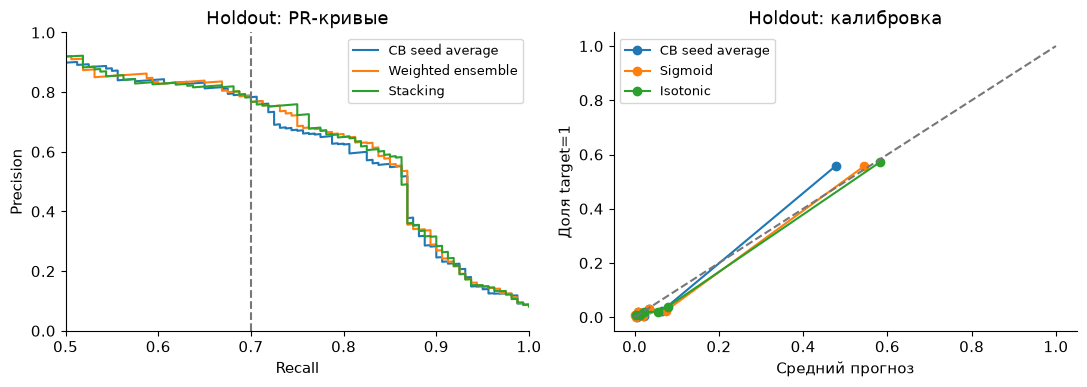

In [4]:
holdout_members = pd.DataFrame({name: seed_average(name, dev_ids, holdout_ids) for name in MEMBERS}, index=holdout_ids)
holdout_meta = fit_meta(dev_ids)
holdout_predictions = meta_predict(holdout_meta, holdout_members)
diagnostic_names = {best_single}
if selected_method.startswith('Single: '):
    diagnostic_names.add(selected_method.removeprefix('Single: '))
for name in diagnostic_names:
    holdout_predictions['Single: ' + name] = seed_average(name, dev_ids, holdout_ids)
holdout_table = pd.DataFrame({name: probability_metrics(y.loc[holdout_ids], score)
                              for name, score in holdout_predictions.items()}).T
display(holdout_table.sort_values('P@R>=0.70', ascending=False).round(4))
calibration_frame, _ = meta_training(dev_ids)
fixed_threshold = threshold_at_recall(y.loc[calibration_frame.index], calibration_frame[BASE])
holdout_diagnostic = pd.DataFrame({'target': y.loc[holdout_ids],
    'score': holdout_predictions['CB seed average'], 'platform': platform.loc[holdout_ids]})
display(segment_metrics(holdout_diagnostic, 'platform', fixed_threshold).round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in ['CB seed average', 'Weighted ensemble', 'Stacking']:
    prec, rec, _ = precision_recall_curve(y.loc[holdout_ids], holdout_predictions[name])
    axes[0].plot(rec, prec, label=name)
axes[0].axvline(.7, color='#777777', linestyle='--')
axes[0].set(xlabel='Recall', ylabel='Precision', title='Holdout: PR-кривые', xlim=(.5, 1), ylim=(0, 1))
axes[0].legend(fontsize=9)
from sklearn.calibration import calibration_curve
for name in ['CB seed average', 'Sigmoid', 'Isotonic']:
    actual, predicted = calibration_curve(y.loc[holdout_ids], holdout_predictions[name], n_bins=8, strategy='quantile')
    axes[1].plot(predicted, actual, marker='o', label=name)
axes[1].plot([0, 1], [0, 1], color='#777777', linestyle='--')
axes[1].set(xlabel='Средний прогноз', ylabel='Доля target=1', title='Holdout: калибровка')
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

## 7. Финальное обучение и файлы для отправки

Все базовые модели переобучаем на полном train. Веса и метамодель переобучаем по той же процедуре на временных OOF-прогнозах внутри полного train: теперь последние дни тоже разрешены как обучающие данные. Test участвует только в расчете собственных оконных признаков и получении прогнозов.

In [ ]:
full_ids = train.cookie_id.to_numpy()
test_ids = test.cookie_id.to_numpy()
final_members = pd.DataFrame({name: seed_average(name, full_ids, test_ids) for name in MEMBERS}, index=test_ids)
final_meta = fit_meta(full_ids)
final_predictions = meta_predict(final_meta, final_members)
extra_names = {best_single}
if selected_method.startswith('Single: '):
    extra_names.add(selected_method.removeprefix('Single: '))
for name in extra_names:
    final_predictions['Single: ' + name] = seed_average(name, full_ids, test_ids)

exports = {
    'submission_cb.csv': ('CB seed average', final_predictions['CB seed average']),
    'submission_cb_motion.csv': ('Single: CB no duplicates', final_members['CB no duplicates'].to_numpy()),
    'submission_hgb.csv': ('Single: HGB pointer', final_members['HGB pointer'].to_numpy()),
    'submission_weighted.csv': ('Weighted ensemble', final_predictions['Weighted ensemble']),
    'submission_stacking.csv': ('Stacking', final_predictions['Stacking']),
    'submission_blending.csv': ('Blending', final_predictions['Blending'])
}
if best_single not in [BASE, 'CB no duplicates']:
    exports['submission_cb_variant.csv'] = ('Single: ' + best_single, final_predictions['Single: ' + best_single])

cv_scores = {**{'Single: ' + k: v for k, v in bag_summary.P_mean.items()},
             **ensemble_results.groupby('model')['P@R>=0.70'].mean().to_dict()}
holdout_scores = {**{'Single: ' + k: holdout_members[k].to_numpy() for k in MEMBERS},
                  **holdout_predictions}

# Единый порядок cookie_id и проверка содержимого после записи.
export_rows = []
for filename, (method, score) in exports.items():
    submission = pd.DataFrame({'cookie_id': test.cookie_id, 'score': np.asarray(score)})
    assert submission.cookie_id.is_unique and submission.score.between(0, 1).all()
    assert set(submission.cookie_id) == set(sample.cookie_id)
    submission.to_csv(filename, index=False)
    restored = pd.read_csv(filename)
    assert restored.cookie_id.equals(test.cookie_id) and restored.score.notna().all()
    np.testing.assert_allclose(restored.score, score, rtol=1e-12, atol=1e-15)
    export_rows.append({'file': filename, 'method': method, 'rows': len(submission),
                       'P_CV': cv_scores[method],
                       'P_holdout': precision_at_recall(y.loc[holdout_ids], holdout_scores[method]),
                       'sha256': hashlib.sha256(Path(filename).read_bytes()).hexdigest()})
export_table = pd.DataFrame(export_rows)
display(export_table[['file', 'method', 'P_CV', 'P_holdout']].round(4))
display(pd.DataFrame({'component': MEMBERS, 'weighted': final_meta['weights'], 'blending': final_meta['blend_weights']}))
display(final_members.corr(method='spearman').round(3))

,file,method,P_CV,P_holdout
0,submission_cb.csv,CB seed average,0.7490,0.7887
1,submission_cb_motion.csv,Single: CB no duplicates,0.7496,0.8071
2,submission_hgb.csv,Single: HGB pointer,0.7349,0.7778
3,submission_weighted.csv,Weighted ensemble,0.7255,0.7887
4,submission_stacking.csv,Stacking,0.7551,0.7832
5,submission_blending.csv,Blending,0.7438,0.7847
6,submission.csv,CB seed average,0.7490,0.7887


,component,weighted,blending
0,CB duplicates,0.0000,0.5000
1,CB no duplicates,0.7500,0.0000
2,HGB pointer,0.0000,0.2500
3,LR balanced,0.2500,0.2500


,CB duplicates,CB no duplicates,HGB pointer,LR balanced
CB duplicates,1.0000,0.9940,0.9190,0.8010
CB no duplicates,0.9940,1.0000,0.9180,0.8020
HGB pointer,0.9190,0.9180,1.0000,0.7520
LR balanced,0.8010,0.8020,0.7520,1.0000


Финальное - submission_stacking, тк наивысшее качество на скрытой выборке + кросс-валидации